# 第036讲 自适应优化与权重衰减
从同一四行数据出发，完整手算两轮、检查优化器历史状态，再比较独立权重衰减。固定图注只对应原始数据；改数据请使用脚本。

In [1]:
from pathlib import Path
import sys, json, hashlib
ROOT=Path.cwd()
BASELINE={'data/regression.csv': '0bd28e7888af84c067bf6e4cec62e6d44e1e53f663f257d078dd104aaabb9105', 'data/model_spec.json': 'a8a82c874efdb9a587310f9bd631832b438bf5725b50ed64d894aa1da6b92607'}
for name,digest in BASELINE.items():
    if hashlib.sha256((ROOT/name).read_bytes()).hexdigest()!=digest:
        raise ValueError('默认输入已改变，固定教学说明不适用：'+name)
sys.path.insert(0,str(ROOT))
import experiment as ex
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction as Q
from decimal import Decimal as D, localcontext
from IPython.display import display, Image
import io,copy
def show(fig):
    b=io.BytesIO();fig.savefig(b,format='png',dpi=130,bbox_inches='tight');display(Image(data=b.getvalue()));plt.close(fig)
data,spec=ex.load_inputs()
print('Default input bytes verified. Python',sys.version.split()[0],'NumPy',np.__version__)
print('Rows:',data.tolist())

Default input bytes verified. Python 3.12.14 NumPy 2.3.5
Rows: [[-2.0, -1.5], [-2.0, -0.5], [2.0, 2.5], [2.0, 3.5]]


## 1 精确第一轮：所有局部量都保留
下面不调用优化器。平均因子只加在梯度累积中；单行损失是残差平方的一半。

In [2]:
rows=[[Q(float(v)) for v in row] for row in data];theta=[Q(0),Q(0)];eta=Q(1,4);beta1=Q(1,2);beta2=Q(3,4);eps=Q(1)
def paper_forward(theta):
    pred=[theta[0]+theta[1]*x for x,y in rows];r=[p-y for p,(x,y) in zip(pred,rows)]
    loss=[rr*rr/2 for rr in r];contrib=[[rr/4,rr*x/4] for rr,(x,y) in zip(r,rows)]
    g=[sum(z[j] for z in contrib) for j in range(2)]
    for i in range(4):print('row',i+1,'pred',pred[i],'r',r[i],'half square',loss[i],'local chain',r[i],'* 1 * [1,',rows[i][0],'] / 4','contribution',list(map(str,contrib[i])))
    print('F',sum(loss)/4,'gradient',list(map(str,g)));return g
g1=paper_forward(theta);m1=[(1-beta1)*g for g in g1];v1=[(1-beta2)*g*g for g in g1];mh1=[m/(1-beta1) for m in m1];vh1=[v/(1-beta2) for v in v1]
theta1=[w-eta*m/(abs(g)+eps) for w,m,g in zip(theta,mh1,g1)]
print('m1',list(map(str,m1)),'v1',list(map(str,v1)),'mhat',list(map(str,mh1)),'vhat',list(map(str,vh1)),'NEW theta',list(map(str,theta1)))
g2=paper_forward(theta1)

row 1 pred 0 r 3/2 half square 9/8 local chain 3/2 * 1 * [1, -2 ] / 4 contribution ['3/8', '-3/4']
row 2 pred 0 r 1/2 half square 1/8 local chain 1/2 * 1 * [1, -2 ] / 4 contribution ['1/8', '-1/4']
row 3 pred 0 r -5/2 half square 25/8 local chain -5/2 * 1 * [1, 2 ] / 4 contribution ['-5/8', '-5/4']
row 4 pred 0 r -7/2 half square 49/8 local chain -7/2 * 1 * [1, 2 ] / 4 contribution ['-7/8', '-7/4']
F 21/8 gradient ['-1', '-4']
m1 ['-1/2', '-2'] v1 ['1/4', '4'] mhat ['-1', '-4'] vhat ['1', '16'] NEW theta ['1/8', '1/5']
row 1 pred -11/40 r 49/40 half square 2401/3200 local chain 49/40 * 1 * [1, -2 ] / 4 contribution ['49/160', '-49/80']
row 2 pred -11/40 r 9/40 half square 81/3200 local chain 9/40 * 1 * [1, -2 ] / 4 contribution ['9/160', '-9/80']
row 3 pred 21/40 r -79/40 half square 6241/3200 local chain -79/40 * 1 * [1, 2 ] / 4 contribution ['-79/160', '-79/80']
row 4 pred 21/40 r -119/40 half square 14161/3200 local chain -119/40 * 1 * [1, 2 ] / 4 contribution ['-119/160', '-119/80'

## 2 第二轮：先新梯度，再使用旧历史
第二次更新含平方根，矩仍可用分数表示；参数与四行新前向用100位Decimal另算。

In [3]:
m2=[beta1*a+(1-beta1)*g for a,g in zip(m1,g2)];v2=[beta2*a+(1-beta2)*g*g for a,g in zip(v1,g2)];mh2=[a/(1-beta1**2) for a in m2];vh2=[a/(1-beta2**2) for a in v2]
print('m2',list(map(str,m2)),'v2',list(map(str,v2)),'mhat2',list(map(str,mh2)),'vhat2',list(map(str,vh2)))
with localcontext() as ctx:
    ctx.prec=100
    def dec(q):return D(q.numerator)/D(q.denominator)
    theta2=[dec(a)-dec(eta)*dec(m)/(dec(v).sqrt()+dec(eps)) for a,m,v in zip(theta1,mh2,vh2)]
    losses=[]
    for i,(x,y) in enumerate(rows):
        p=theta2[0]+theta2[1]*dec(x);r=p-dec(y);ell=r*r/2;losses.append(ell)
        print('row',i+1,'prediction',str(p),'residual',str(r),'half square',str(ell))
    print('theta2',list(map(str,theta2)),'F2',str(sum(losses)/4))

m2 ['-11/16', '-13/5'] v2 ['97/256', '139/25'] mhat2 ['-11/12', '-52/15'] vhat2 ['97/112', '2224/175']
row 1 prediction -0.5360077611621723257106904831744862440080922429649980714307404616403881737462211490914435582079801148 residual 0.9639922388378276742893095168255137559919077570350019285692595383596118262537788509085564417920198852 half square 0.4646405182697836971474641465018423187282591208943415058930868565552014332567664396172614854801021769
row 2 prediction -0.5360077611621723257106904831744862440080922429649980714307404616403881737462211490914435582079801148 residual -0.0360077611621723257106904831744862440080922429649980714307404616403881737462211490914435582079801148 half square 0.0006482794319560228581546296763285627363513638593395773238273181955896070029875887087050436880822917065
row 3 prediction 1.023408729412189843512739013398244349622538151402539436265238083657712460824664927143103837422221356 residual -1.476591270587810156487260986601755650377461848597460563734761916342

## 3 从零代码实际运行
闭式解不参与更新。主方法保留每次旧/新前向、全部状态、方向、系数和实际位移。

In [4]:
report=ex.run_experiment(data,spec);methods=report['methods']
for name,p in methods.items():print(name,p['status'],'sample gradients',p['training_sample_gradients'],'final theta',p['final_state']['theta'])
print('Complete report SHA256',hashlib.sha256(ex.report_bytes(report)).hexdigest())
for t in range(2):
    tr=methods['Adam']['trace'][t]
    print('update',t+1,'g',tr['data_gradient'],'m',tr['new_state']['m'],'v',tr['new_state']['v'],'direction',tr['direction'],'denominator',tr['denominator'],'delta',tr['actual_delta'])

GD fixed_budget_completed sample gradients 400 final theta [0.9999999999996793, 1.0]
AdaGrad fixed_budget_completed sample gradients 400 final theta [0.9996671968837071, 0.9999975679392301]
RMSProp fixed_budget_completed sample gradients 400 final theta [0.999999999997973, 1.0]
Adam fixed_budget_completed sample gradients 400 final theta [0.9999999999999988, 1.0000000000000009]
AdamL2 fixed_budget_completed sample gradients 400 final theta [1.0000000000000007, 0.9756097560975578]
AdamW fixed_budget_completed sample gradients 400 final theta [1.0000000000000007, 0.973051483510165]


Complete report SHA256 15c8e5460ca7c03b20a5e0c1be6067a9f05e1d6af330463a749323e0461befce
update 1 g [-1.0, -4.0] m [-0.5, -2.0] v [0.25, 4.0] direction [-1.0, -4.0] denominator [2.0, 5.0] delta [0.125, 0.2]
update 2 g [-0.875, -3.2] m [-0.6875, -2.6] v [0.37890625, 5.5600000000000005] direction [-0.9166666666666666, -3.466666666666667] denominator [1.9306295871996704, 4.5649083338245084] delta [0.11870048412500872, 0.18985412264359053]


## 4 同预算与预先声明的学习率网格
目标差由本数据的闭式稳定计算，避免用两个近似相同目标相减。GD大步长也保留，不能删掉失败曲线来宣布赢家。

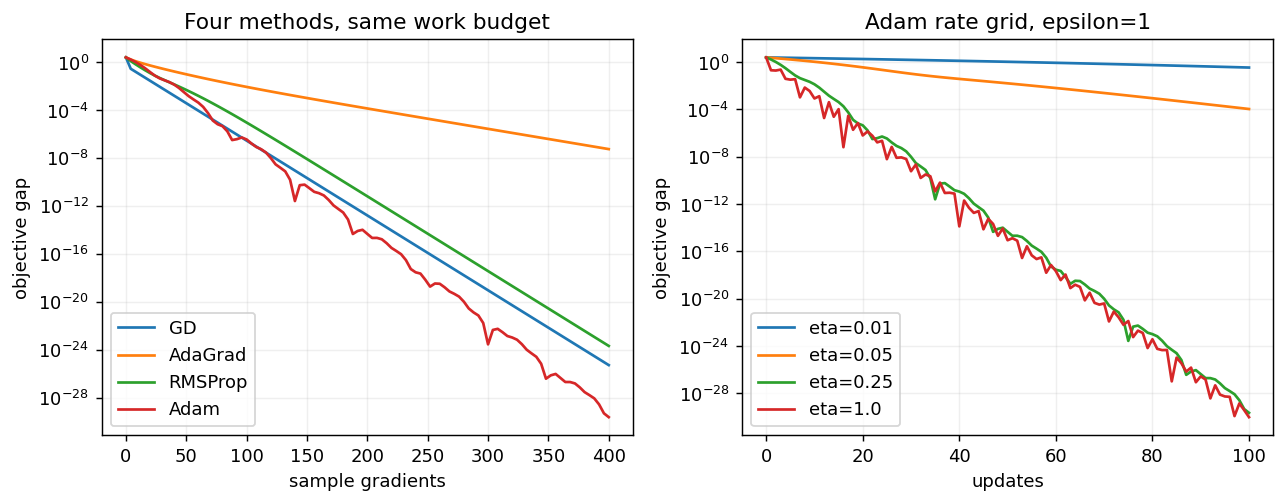

In [5]:
fig,axs=plt.subplots(1,2,figsize=(10,4))
for name in ['GD','AdaGrad','RMSProp','Adam']:
    c=ex.compact(methods[name])['curve'];axs[0].semilogy([4*z['t'] for z in c],np.maximum([z['default_gap'] for z in c],1e-30),label=name)
for eta in spec['rate_grid']:
    c=report['grid'][f'Adam:eta={eta}:eps=1.0']['curve'];axs[1].semilogy([z['t'] for z in c],np.maximum([z['default_gap'] for z in c],1e-30),label='eta='+str(eta))
axs[0].set(xlabel='sample gradients',ylabel='objective gap',title='Four methods, same work budget');axs[1].set(xlabel='updates',ylabel='objective gap',title='Adam rate grid, epsilon=1')
for ax in axs:ax.legend();ax.grid(alpha=.2)
fig.tight_layout();show(fig)

## 5 有效系数乘的是历史方向
四个面板来自相同第二轮；系数不是实际位移，更不能在g=0时用位移除g定义它。

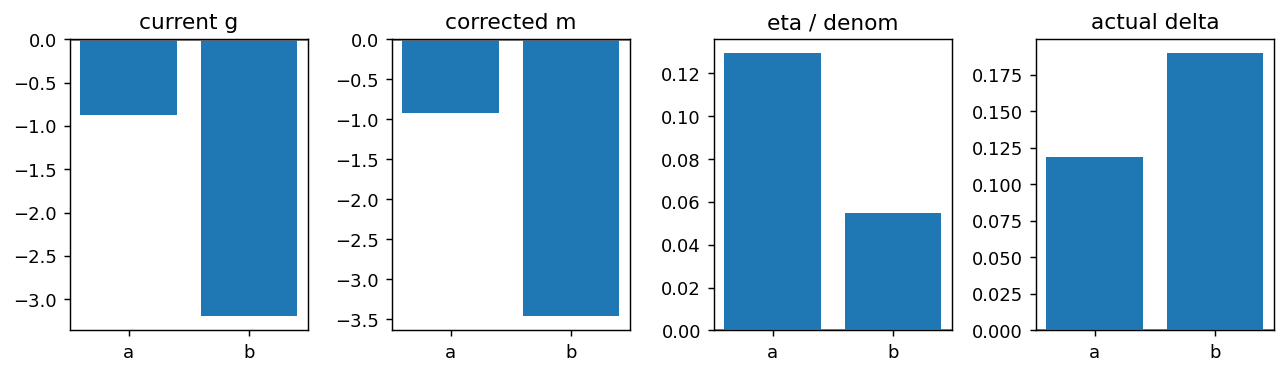

In [6]:
tr=methods['Adam']['trace'][1];fig,axs=plt.subplots(1,4,figsize=(10,3))
for ax,key,title in zip(axs,['data_gradient','direction','effective_coefficient','actual_delta'],['current g','corrected m','eta / denom','actual delta']):
    ax.bar(['a','b'],tr[key]);ax.axhline(0,color='gray');ax.set_title(title)
fig.tight_layout();show(fig)

## 6 非零初值的耦合与解耦两轮
打印每行旧预测/残差/损失、梯度分项，矩状态与两个位移，最后重新前向。F与F+L2分别列出。

AdamL2 update 1
old_forward theta [0.5, -0.5] F 4.75
{'row': 1, 'x': -2.0, 'y': -1.5, 'prediction': 1.5, 'residual': 3.0, 'half_square': 4.5, 'dhalf_square_dresidual': 3.0, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': -2.0, 'scaled_mean_gradient_contribution': [0.75, -1.5]}
{'row': 2, 'x': -2.0, 'y': -0.5, 'prediction': 1.5, 'residual': 2.0, 'half_square': 2.0, 'dhalf_square_dresidual': 2.0, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': -2.0, 'scaled_mean_gradient_contribution': [0.5, -1.0]}
{'row': 3, 'x': 2.0, 'y': 2.5, 'prediction': -0.5, 'residual': -3.0, 'half_square': 4.5, 'dhalf_square_dresidual': -3.0, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': 2.0, 'scaled_mean_gradient_contribution': [-0.75, -1.5]}
{'row': 4, 'x': 2.0, 'y': 3.5, 'prediction': -0.5, 'residual': -4.0, 'half_square': 8.0, 'dhalf_square_dresidual': -4.0, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': 2.0, 'scale

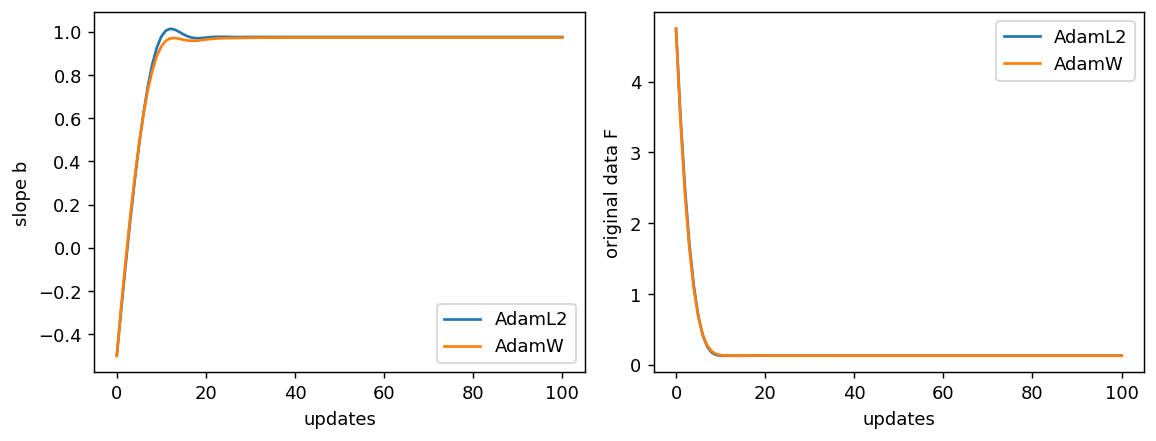

In [7]:
for name in ['AdamL2','AdamW']:
    for tr in methods[name]['trace'][:2]:
        print(name,'update',tr['update'])
        for which in ['old_forward','new_forward']:
            print(which,'theta',tr[which]['theta'],'F',tr[which]['data_loss'])
            for row in tr[which]['rows']:print(row)
        print('data g',tr['data_gradient'],'penalty g',tr['regularizer_gradient'],'used g',tr['used_gradient'],'m',tr['new_state']['m'],'v',tr['new_state']['v'])
        print('adaptive delta',tr['adaptive_delta'],'old-parameter decay delta',tr['decay_delta'],'new F+L2',tr['new_F_plus_L2'])
fig,axs=plt.subplots(1,2,figsize=(9,3.5))
for name in ['AdamL2','AdamW']:
    c=ex.compact(methods[name])['curve'];axs[0].plot([z['t'] for z in c],[z['theta'][1] for z in c],label=name);axs[1].plot([z['t'] for z in c],[z['F'] for z in c],label=name)
axs[0].set(xlabel='updates',ylabel='slope b');axs[1].set(xlabel='updates',ylabel='original data F')
for ax in axs:ax.legend()
fig.tight_layout();show(fig)

## 7 缩放整个目标时，ε也有单位
乘100后匹配ε×100恢复同一路径；保持ε会改变路径。平方根内外也另画，不能混名。

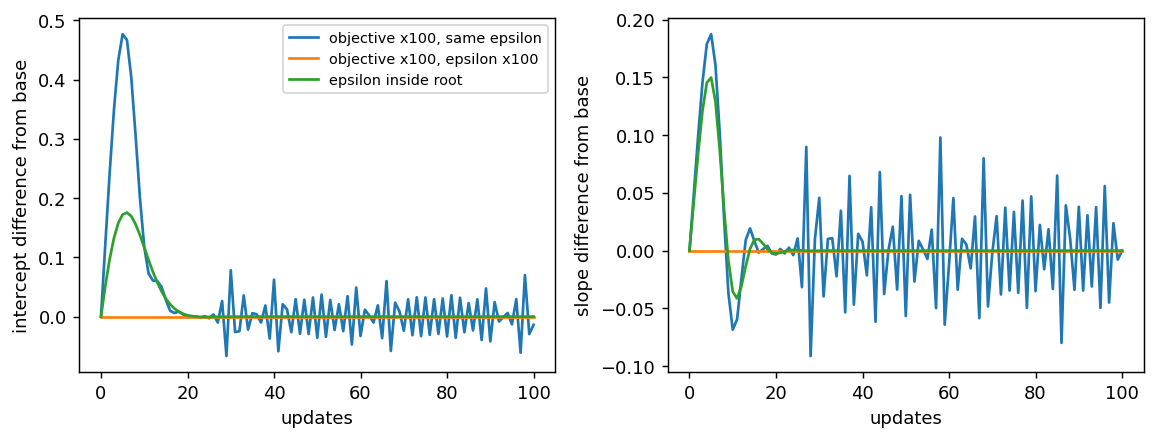

matched maximum parameter difference 2.220446049250313e-16


In [8]:
base=ex.compact(methods['Adam'])['curve'];probe=report['scale_probe'];fig,axs=plt.subplots(1,2,figsize=(9,3.5))
for key,label in [('same_epsilon','objective x100, same epsilon'),('matched_epsilon','objective x100, epsilon x100'),('inside_root','epsilon inside root')]:
    c=probe[key]['curve'];diff=np.array([z['theta'] for z in c])-np.array([z['theta'] for z in base]);axs[0].plot([z['t'] for z in c],diff[:,0],label=label);axs[1].plot([z['t'] for z in c],diff[:,1],label=label)
axs[0].set(xlabel='updates',ylabel='intercept difference from base');axs[1].set(xlabel='updates',ylabel='slope difference from base');axs[0].legend(fontsize=8);fig.tight_layout();show(fig)
print('matched maximum parameter difference',np.max(np.abs(np.array([z['theta'] for z in probe['matched_epsilon']['curve']])-np.array([z['theta'] for z in base]))))

## 8 同一数据的近最优超调
这次ε=1e−8，η=0.25，初值(1+1e−6,1)。数值不是推荐设置；查看所有旧行与新行确认反例确实来自原目标。

old_forward theta [1.000001, 1.0] F 0.1250000000005 stable gap 4.999999999177334e-13
{'row': 1, 'x': -2.0, 'y': -1.5, 'prediction': -0.9999990000000001, 'residual': 0.5000009999999999, 'half_square': 0.12500050000049995, 'dhalf_square_dresidual': 0.5000009999999999, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': -2.0, 'scaled_mean_gradient_contribution': [0.12500024999999998, -0.25000049999999996]}
{'row': 2, 'x': -2.0, 'y': -0.5, 'prediction': -0.9999990000000001, 'residual': -0.4999990000000001, 'half_square': 0.12499950000050004, 'dhalf_square_dresidual': -0.4999990000000001, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dprediction_db': -2.0, 'scaled_mean_gradient_contribution': [-0.12499975000000002, 0.24999950000000004]}
{'row': 3, 'x': 2.0, 'y': 2.5, 'prediction': 3.000001, 'residual': 0.5000010000000001, 'half_square': 0.12500050000050006, 'dhalf_square_dresidual': 0.5000010000000001, 'dresidual_dprediction': 1.0, 'dprediction_da': 1.0, 'dpredict

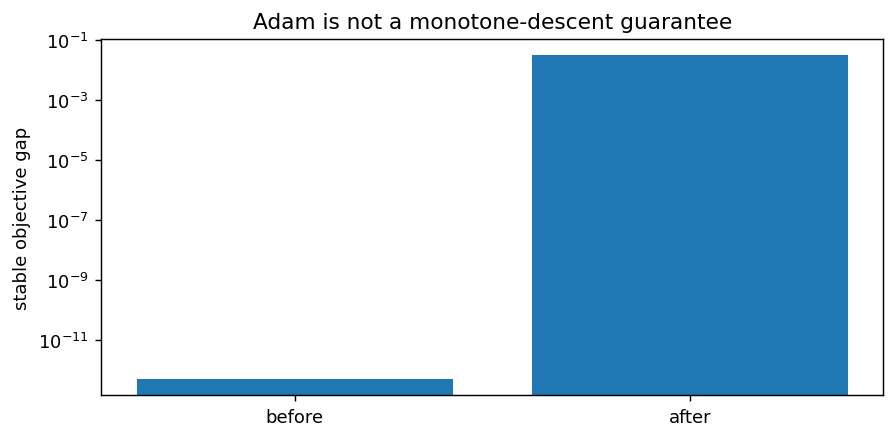

In [9]:
tr=report['near_declared_point_probe']['trace'][0]
for key in ['old_forward','new_forward']:
    print(key, 'theta',tr[key]['theta'],'F',tr[key]['data_loss'],'stable gap',tr[key]['default_closed_form_gap'])
    for row in tr[key]['rows']:print(row)
print('g',tr['data_gradient'],'m',tr['new_state']['m'],'v',tr['new_state']['v'],'mhat',tr['direction'],'delta',tr['actual_delta'])
fig,ax=plt.subplots(figsize=(7,3.5));ax.bar(['before','after'],[tr['old_forward']['default_closed_form_gap'],tr['new_forward']['default_closed_form_gap']]);ax.set_yscale('log');ax.set(ylabel='stable objective gap',title='Adam is not a monotone-descent guarantee');fig.tight_layout();show(fig)

## 9 完整恢复与只存参数
第7轮保存全部状态，后续trace逐字段完全相同。重置历史与时间索引会造成分叉。

{'GD': True, 'AdaGrad': True, 'RMSProp': True, 'Adam': True, 'AdamL2': True, 'AdamW': True}


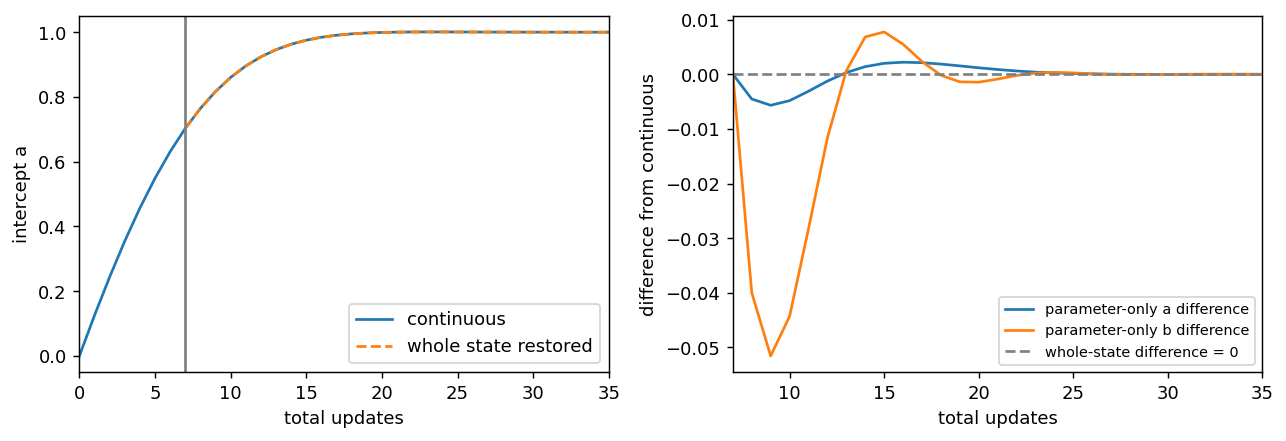

In [10]:
print({name:item['identical_suffix'] for name,item in report['resume'].items()})
split=spec['resume_split'];fig,axs=plt.subplots(1,2,figsize=(10,3.5))
base=ex.compact(methods['Adam'])['curve'];resumed=report['resume']['Adam']['resumed']['curve'];restarted=report['parameter_only_restart']['Adam']['curve']
for c,label,style in [(base,'continuous','-'),(resumed,'whole state restored','--')]:axs[0].plot([z['t'] for z in c],[z['theta'][0] for z in c],style,label=label)
axs[0].axvline(split,color='gray');axs[0].set(xlim=(0,35),xlabel='total updates',ylabel='intercept a');axs[0].legend()
diff=np.array([z['theta'] for z in restarted])-np.array([z['theta'] for z in base[split:]])
for j in range(2):axs[1].plot([z['t']+split for z in restarted],diff[:,j],label=['parameter-only a difference','parameter-only b difference'][j])
axs[1].axhline(0,color='gray',ls='--',label='whole-state difference = 0');axs[1].set(xlim=(7,35),xlabel='total updates',ylabel='difference from continuous');axs[1].legend(fontsize=8);fig.tight_layout();show(fig)

## 10 非法尾字段先拒绝
把step替换为哨兵，只验证错误配置与checkpoint，不执行任何参数更新。Python -O也不能关闭这种校验。

In [11]:
saved_step=ex.step;ex.step=lambda *a: (_ for _ in ()).throw(RuntimeError('不应执行step'))
try:
    bad=copy.deepcopy(spec);bad['epsilon_grid']=[1,True]
    try:ex.run_experiment(data,bad)
    except ValueError as err:print('bad config rejected:',str(err))
    else:raise RuntimeError('非法配置被接受')
    state=copy.deepcopy(methods['Adam']['trace'][6]['new_state']);state['v'][-1]=-1
    try:ex.run_path(data,spec,'Adam',resume=state)
    except ValueError as err:print('bad checkpoint rejected:',str(err))
    else:raise RuntimeError('非法checkpoint被接受')
finally:ex.step=saved_step

bad config rejected: epsilon_grid must be a real scalar, not bool/string/extended precision
bad checkpoint rejected: state v must be nonnegative


## 11 可选真实PyTorch对照
独立运行library_check.py会实际创建CPU float64优化器，核对全部参数和状态。这里读取随单元附带的已执行结果，明确它不是本Notebook即时导入PyTorch。要重验请按实验指南使用固定可选环境。

In [12]:
library=json.loads((ROOT/'library-result.json').read_text())
print('Recorded independently executed library check:',library['torch'],library['device'],library['dtype'],'checks',library['checks'])
print('maximum absolute difference',library['maximum_absolute_difference'],'tolerance',library['tolerance'])
print('zero vs None:',library['zero_vs_none'])
print('zero current gradient with history:',library['zero_current_gradient_with_history'])

Recorded independently executed library check: 2.7.1+cpu CPU float64 checks 4141
maximum absolute difference 5.684341886080802e-14 tolerance {'rtol': 2e-11, 'atol': 2e-12}
zero vs None: {'zero': {'parameter': -0.4875, 'step': 1.0, 'state_created': True}, 'none': {'parameter': -0.5, 'step': None, 'state_created': False}}
zero current gradient with history: {'before_zero_gradient': 0.33333333333333337, 'after_zero_gradient': 0.2611616203362774, 'm': 0.5, 'v': 0.75, 'step': 2.0}


## 12 完整报告与科学边界
最后校验全部默认方法的预算、恢复与有限性，再保存本次真实计算报告。图像只是报告的一部分。

In [13]:
for name,p in methods.items():
    if p['training_sample_gradients']!=400 or not report['resume'][name]['identical_suffix']:raise RuntimeError('预算或恢复不一致')
payload=ex.write_report(report,ROOT/'notebook_results',[ROOT/'data/regression.csv',ROOT/'data/model_spec.json'])
print('Complete report written. SHA256',hashlib.sha256(payload).hexdigest())
print('有限合成实验不证明Adam普遍更好，也不证明泛化或硬件速度。')

Complete report written. SHA256 15c8e5460ca7c03b20a5e0c1be6067a9f05e1d6af330463a749323e0461befce
有限合成实验不证明Adam普遍更好，也不证明泛化或硬件速度。
